# run20 — 추가 데이터 분석 차트 (전처리·EDA, H1~H4/Uplift와 독립)

이 노트북은 `전처리_리포트.html` 아티팩트에 넣을 4가지 추가 데이터 분석의 차트를 실제 데이터로 생성한다.
1. 외부 경제지표 vs 월매출 상관분석
2. 요일 x 시간대별 구매패턴
3. 연령대 x 상품카테고리 선호 히트맵
4. 이상거래 계정(abnormal_account_flag) 프로파일링

결과 이미지는 `run20_charts/` 폴더에 PNG로 저장됨.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13

GREEN = '#2f6b4f'
GREEN_SOFT = '#7dc49a'
AMBER = '#a85c1c'
BLUE = '#3a5f8a'
RED = '#b3311f'
GREY = '#8a9488'

BASE = "C:/Users/aidan/OneDrive/바탕 화면/종합실습/data/processed/"
OUT_DIR = BASE + "run20_charts/"
os.makedirs(OUT_DIR, exist_ok=True)
print("준비 완료")

준비 완료


## 1. 외부 경제지표 vs 월매출 상관분석

지금까지 13개 외부변수를 데이터에 붙이기만 했고, 실제로 매출과의 상관관계를 계산해본 적은 없었다. 월별 매출 합계와 5개 주요 외부지표(기준금리·CCSI·신선식품지수·유가·농축수산물지수)의 Pearson 상관계수를 계산한다. 11월은 반쪽 달(11/16까지만 집계)이라 제외.

기준금리      -0.620196
유가        -0.589589
신선식품지수    -0.202234
농축수산물지수    0.024507
CCSI       0.565878
Name: 매출, dtype: float64


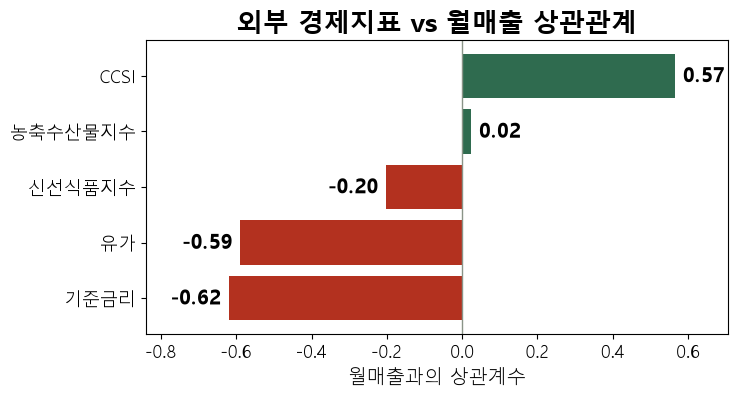

In [2]:
df1 = pd.read_csv(BASE + "merged_master.csv", encoding="utf-8-sig",
    usecols=["주문일시", "구매금액", "주문취소여부", "기준금리(%)", "신선식품지수_전월대비(%)",
             "소비자심리지수_CCSI", "두바이유_평균유가(달러/배럴)", "농축수산물지수_전월대비(%)"])
df1 = df1[df1["주문취소여부"] != "주문취소"].copy()
df1["month"] = pd.to_datetime(df1["주문일시"]).dt.to_period("M")

monthly = df1.groupby("month").agg(매출=("구매금액", "sum")).reset_index()
ext = df1.groupby("month").agg(
    기준금리=("기준금리(%)", "first"),
    CCSI=("소비자심리지수_CCSI", "first"),
    신선식품지수=("신선식품지수_전월대비(%)", "first"),
    유가=("두바이유_평균유가(달러/배럴)", "first"),
    농축수산물지수=("농축수산물지수_전월대비(%)", "first"),
).reset_index()
m = monthly.merge(ext, on="month")
m = m[m["month"].astype(str) < "2025-11"]

corr = m[["매출", "기준금리", "CCSI", "신선식품지수", "유가", "농축수산물지수"]].corr()["매출"].drop("매출").sort_values()
print(corr)

fig, ax = plt.subplots(figsize=(7.6, 4.2))
colors = [RED if v < 0 else GREEN for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color=GREY, lw=1)
ax.set_xlim(corr.min() - 0.22, corr.max() + 0.14)
ax.set_xlabel("월매출과의 상관계수")
ax.set_title("외부 경제지표 vs 월매출 상관관계", fontsize=19, fontweight='bold')
for i, v in enumerate(corr.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:.2f}", va='center', ha='left' if v >= 0 else 'right', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + "01_외부지표_매출상관.png", dpi=150, facecolor='white')
plt.show()

## 2. 요일 x 시간대별 구매패턴

`주문시간` 컬럼은 "오전/오후 HH:MM" 형식이며, `분=60`인 포맷 오류가 1.6%(전처리 계획에 명시돼 있었으나 시간대 분석이 필요해질 때까지 보류돼 있던 항목)가 있어 이번에 직접 보정한다(시+1, 분0).

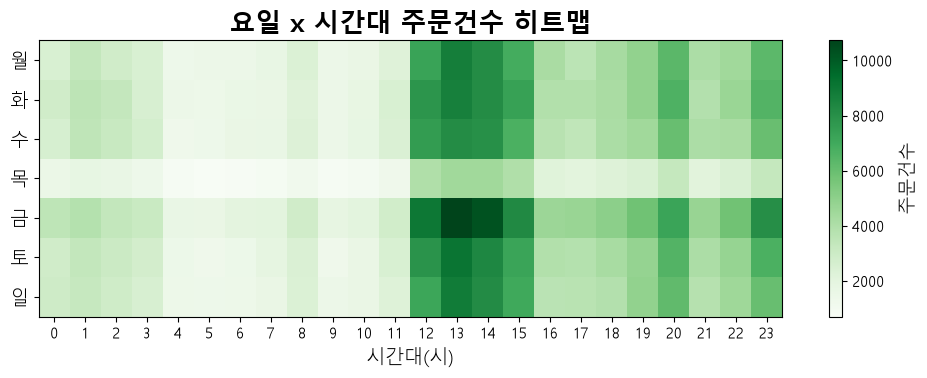

가장 주문 많은 시간대: 13시, 가장 주문 많은 요일: 금요일


In [3]:
raw = pd.read_csv(BASE + "merged_master.csv", encoding="utf-8-sig",
                   usecols=["주문일시", "주문시간", "주문취소여부"])
raw = raw[raw["주문취소여부"] != "주문취소"].copy()

def parse_hour(s):
    try:
        ampm, hm = s.split()
        h, mi = hm.split(":")
        h, mi = int(h), int(mi)
        if mi == 60:
            mi = 0
            h += 1
        if ampm == "오전":
            if h == 12:
                h = 0
        else:
            if h != 12:
                h += 12
        return h % 24
    except Exception:
        return np.nan

raw["hour"] = raw["주문시간"].apply(parse_hour)
raw["요일"] = pd.to_datetime(raw["주문일시"]).dt.day_name()
order_map = {"Monday": "월", "Tuesday": "화", "Wednesday": "수", "Thursday": "목",
             "Friday": "금", "Saturday": "토", "Sunday": "일"}
raw["요일한글"] = raw["요일"].map(order_map)
weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

pivot = raw.pivot_table(index="요일한글", columns="hour", values="주문일시", aggfunc="count").reindex(weekday_order).fillna(0)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='Greens')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=11)
ax.set_yticks(range(7))
ax.set_yticklabels(weekday_order, fontsize=14)
ax.set_xlabel("시간대(시)")
ax.set_title("요일 x 시간대 주문건수 히트맵", fontsize=19, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label="주문건수")
cbar.ax.tick_params(labelsize=11)
cbar.set_label("주문건수", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR + "02_요일시간대_히트맵.png", dpi=150, facecolor='white')
plt.show()

peak_hour = pivot.sum(axis=0).idxmax()
peak_day = pivot.sum(axis=1).idxmax()
print(f"가장 주문 많은 시간대: {peak_hour}시, 가장 주문 많은 요일: {peak_day}요일")

## 3. 연령대 x 상품카테고리 선호 히트맵

대시보드에는 세그먼트별 top5 인기품목 리스트만 있었고, 연령대 전체 x 카테고리 전체를 한 장에 보여주는 히트맵은 없었다. 구매건수 상위 12개 물품중분류로 한정해 연령대별 구매비중(%)을 계산한다.

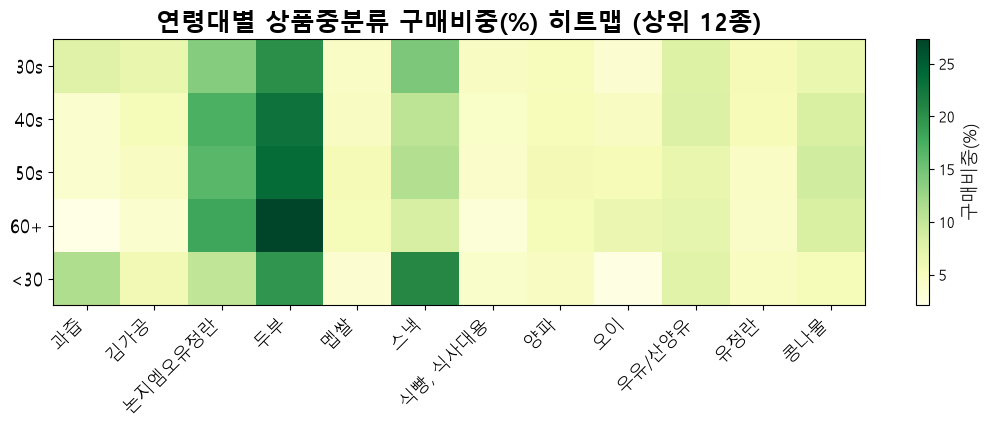

In [4]:
df3 = pd.read_csv(BASE + "merged_master_enriched.csv", encoding="utf-8-sig",
                   usecols=["age_band_h4", "물품중분류", "is_cancelled"])
df3 = df3[df3["is_cancelled"] == 0]
top_cats = df3["물품중분류"].value_counts().head(12).index
df3f = df3[df3["물품중분류"].isin(top_cats)]
pivot3 = pd.crosstab(df3f["age_band_h4"], df3f["물품중분류"], normalize='index') * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(pivot3.values, aspect='auto', cmap='YlGn')
ax.set_xticks(range(len(pivot3.columns)))
ax.set_xticklabels(pivot3.columns, rotation=45, ha='right', fontsize=13)
ax.set_yticks(range(len(pivot3.index)))
ax.set_yticklabels(pivot3.index, fontsize=14)
ax.set_title("연령대별 상품중분류 구매비중(%) 히트맵 (상위 12종)", fontsize=18, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label="구매비중(%)")
cbar.ax.tick_params(labelsize=11)
cbar.set_label("구매비중(%)", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR + "03_연령대_카테고리_히트맵.png", dpi=150, facecolor='white')
plt.show()

## 4. 이상거래 계정 프로파일링

전처리 단계에서 `abnormal_account_flag`(주문 상위 1%)를 플래그만 해두고 실제 특성 비교는 안 했었다. 정상계정과 이상계정의 평균 주문건수·총구매액·객단가를 비교한다.

                          인원  평균frequency  평균monetary    평균aov
abnormal_account_flag                                         
0                      11613         12.2    468341.3  37397.1
1                        119        123.8   5794921.9  46178.0


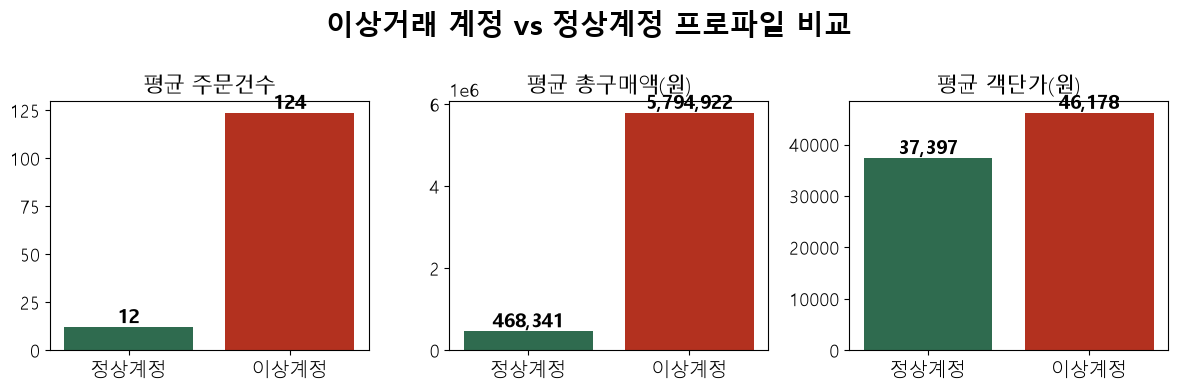

In [5]:
snap = pd.read_csv(BASE + "snapshot_train.csv", encoding="utf-8-sig",
                    usecols=["회원번호", "abnormal_account_flag", "frequency", "monetary", "aov"])
profile = snap.groupby("abnormal_account_flag").agg(
    인원=("회원번호", "count"),
    평균frequency=("frequency", "mean"),
    평균monetary=("monetary", "mean"),
    평균aov=("aov", "mean"),
).round(1)
print(profile)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels = ["정상계정", "이상계정"]
metrics = [("평균frequency", "평균 주문건수"), ("평균monetary", "평균 총구매액(원)"), ("평균aov", "평균 객단가(원)")]
for ax, (col, title) in zip(axes, metrics):
    ax.bar(labels, profile[col], color=[GREEN, RED])
    ax.tick_params(axis='x', labelsize=14)
    ax.set_title(title, fontsize=15)
    for i, v in enumerate(profile[col]):
        ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=14, fontweight='bold')
fig.suptitle("이상거래 계정 vs 정상계정 프로파일 비교", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + "04_이상계정_프로파일.png", dpi=150, facecolor='white')
plt.show()

## 요약

생성된 4개 이미지는 `run20_charts/` 폴더에 저장됨: `01_외부지표_매출상관.png`, `02_요일시간대_히트맵.png`, `03_연령대_카테고리_히트맵.png`, `04_이상계정_프로파일.png`